# COMPARANDO MODELOS DE REGRESIÓN PARA DATASET INSURANCE
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [47]:
%run '/content/pandas_missing_extension.ipynb'

In [48]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [49]:
df = pd.read_csv('telco_data_transformed.csv')
df

,gender,partner,dependents,phone_service,paperless_billing,churn,device_protection_no,device_protection_noservice,device_protection_yes,movies_no,...,security_no,security_noservice,security_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,74.40,306.60


 # PASO 3 : EDA

## VERIFICAMOS SI HAY VALORES NULOS

In [56]:
df.isna().sum().sum()

np.int64(0)

In [53]:
df.missing.number_missing()

np.int64(11)

In [54]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [55]:
df.dropna(subset=['total_charges'], inplace=True)

# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

## 4.3 DIVIDO LAS VARIABLES POR TIOP DE CODIFICACIÓN(LABEL Y ONE HOT ENCODING)

## 4.4 CODIFICAMOS USANDO LOS MODULOS COMPOSE Y PREPROCESSING DE SKLEARN

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

# 5 - CORRELACIONES

In [57]:
corr_matrix = df.corr()
corr_charges = corr_matrix['total_charges']
corr_charges.sort_values(ascending=False)

,total_charges
total_charges,1.000000
tenure,0.825880
monthly_charges,0.651065
device_protection_yes,0.522881
movies_yes,0.519867
tv_yes,0.515709
backup_yes,0.510100
multiple_lines_yes,0.469042
tech_support_yes,0.432868
security_yes,0.412619


<Axes: >

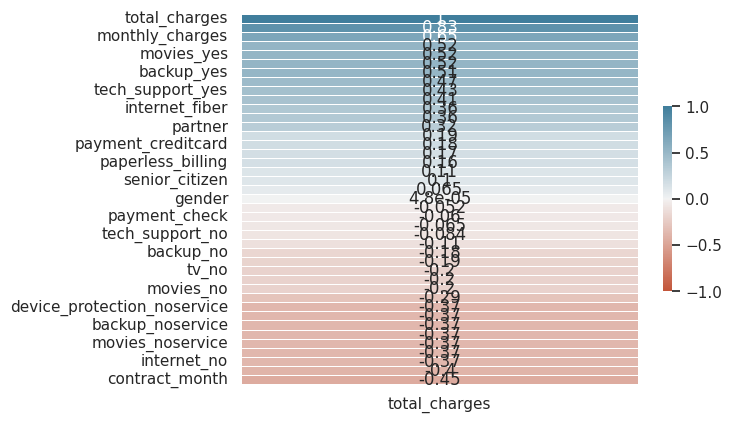

In [58]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [59]:
cols = corr_charges.index.tolist()
cols.remove('total_charges')
cols

['gender',
 'partner',
 'dependents',
 'phone_service',
 'paperless_billing',
 'churn',
 'device_protection_no',
 'device_protection_noservice',
 'device_protection_yes',
 'movies_no',
 'movies_noservice',
 'movies_yes',
 'contract_month',
 'contract_year',
 'contract_twoyears',
 'multiple_lines_no',
 'multiple_lines_noservice',
 'multiple_lines_yes',
 'tech_support_no',
 'tech_support_noservice',
 'tech_support_yes',
 'payment_transfer',
 'payment_creditcard',
 'payment_check',
 'payment_mail',
 'tv_no',
 'tv__no internet service',
 'tv_yes',
 'backup_no',
 'backup_noservice',
 'backup_yes',
 'security_no',
 'security_noservice',
 'security_yes',
 'internet_dsl',
 'internet_fiber',
 'internet_no',
 'senior_citizen',
 'tenure',
 'monthly_charges']

# 6 - ENTRENAMIENTO DEL MODELO

In [60]:
#X_cols = ['smoker','age','bmi']
X_cols = cols
y_col = ['total_charges']

In [61]:
X = df[X_cols].values
y = df[y_col].values.reshape(-1,1)

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [63]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 2 - ESCALAMIENTO DE DATOS

In [64]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [65]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [66]:
results = {}
for name,model in models.items():
    model.fit(X_train_scaled,y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    r2 = r2_score(y_test_scaled,y_pred_scaled)
    mse = mean_squared_error(y_test_scaled,y_pred_scaled)
    mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
    results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [67]:
results_df = pd.DataFrame(results).T
results_df

,R2,MSE,MAE
Linear Regression,0.913236,0.089883,0.240941
Lasso,0.882190,0.122046,0.272466
Ridge,0.913208,0.089913,0.241009
KNN Regressor,0.850927,0.154433,0.268343
SVR,0.909476,0.093779,0.238262
Random Forest Regressor,0.998740,0.001305,0.024309


# BUSCAMOS EL MEJOR MODELO

In [68]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.9987)
Best model based on MSE: Random Forest Regressor (MSE: 0.00)


# GRAFICAMOS METRICAS DE LOS MODELOS

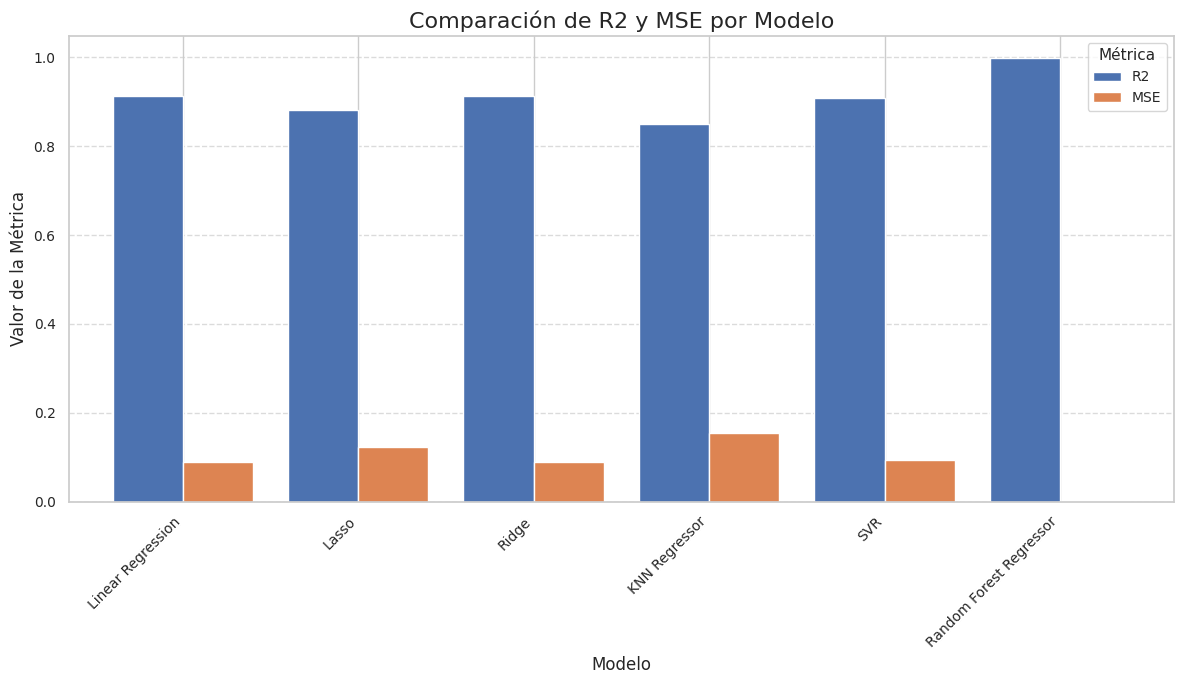

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()